In [7]:
import matplotlib.pyplot as plt
import os
#from utilites import read_data_from_timestep
import numpy as np
import pandas as pd
import csv


rho_ratio = '1'
v = '0001'
U='001'


folder_path_moving = os.path.join("~/DATA_FOR_PLOTS",
                           "moving_vs_resting_bubble","oscillating_batch",
                           f"rho{rho_ratio}_v{v}_oscillating_U{U}","line_data")

folder_path_resting = os.path.join("~/DATA_FOR_PLOTS",
                           "moving_vs_resting_bubble","oscillating_batch",
                           f"rho{rho_ratio}_v{v}_oscillating_U{U}","line_data")

n = np.arange(0, 999, 1)  # [from, to, step]

diam_x_cm_resting = np.empty(len(n))   # x coordinate of the center of mass of the bubble
diam_x_mrt_resting = np.empty(len(n))  # x coordinate of the center of mass of the bubble
diam_x_cm_moving = np.empty(len(n))    # x coordinate of the center of mass of the bubble
diam_x_mrt_moving = np.empty(len(n))   # x coordinate of the center of mass of the bubble

for i in n:
    def load_data(path):
        try:
            frame_moving = pd.read_csv(path, delimiter=",")              
            return frame_moving     
        except FileNotFoundError:
            print(f"Wrong file or file path: {path}")
            return None
                     
    frame_cm_resting = load_data(os.path.join(folder_path_resting, f"cm_resting.{i}.csv"))    
    frame_mrt_resting = load_data(os.path.join(folder_path_resting, f"mrt_resting.{i}.csv"))       
    frame_cm_moving = load_data(os.path.join(folder_path_moving, f"cm_moving.{i}.csv"))
    frame_mrt_moving = load_data(os.path.join(folder_path_moving, f"mrt_moving.{i}.csv"))

    def find_diameter(frame, threshold=0.5): 
        if frame is None:
            return None
                                      
        # paraview dumps 1001 grid points from line plot, 
        # while simluation domain is 256 
        x_max = max(frame['Points:0']) # 256
        n= len(frame['Points:0'])  # 1001
        scale_factor =x_max/n

        counter = 0
        for y_ in frame['PhaseField']:
            counter += y_
#             if y_ > threshold:
#                 counter += 1

        ans = counter*scale_factor
        return ans
   
    diam_x_cm_resting[i] = find_diameter(frame_cm_resting)
    diam_x_mrt_resting[i] = find_diameter(frame_mrt_resting)
    diam_x_cm_moving[i] = find_diameter(frame_cm_moving)
    diam_x_mrt_moving[i] = find_diameter(frame_mrt_moving)
                                  

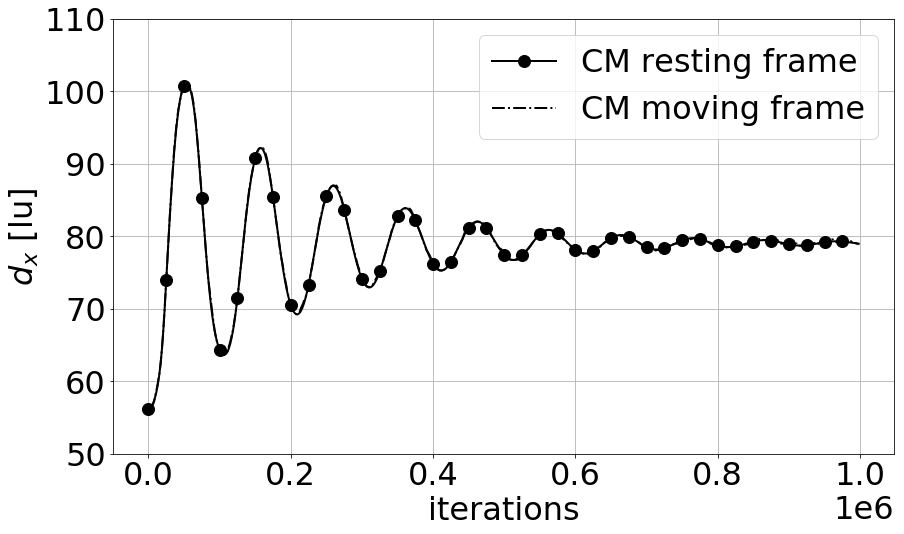

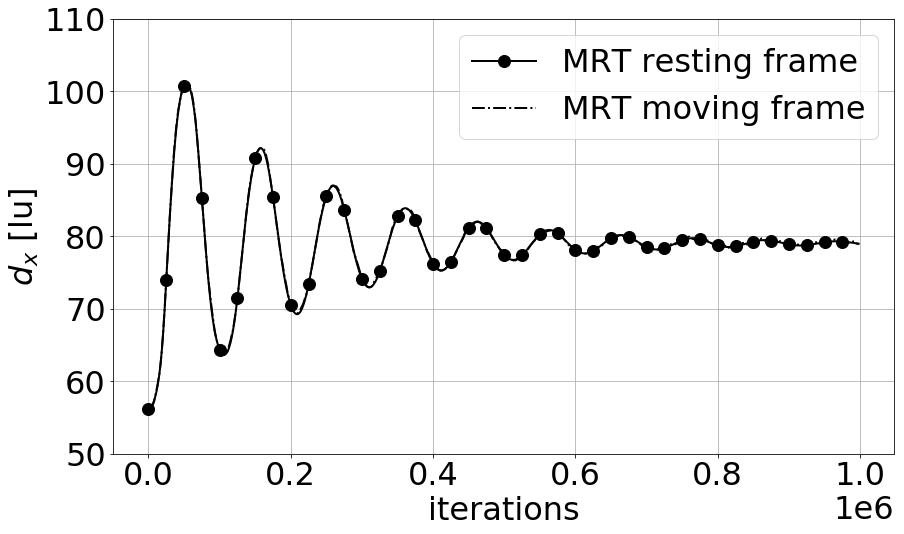

In [8]:
# make plot
def make_plot(x1, y1, x2, y2, fig_name, y_label, label1, label2):
    plt.rcParams.update({'font.size': 32})
    plt.figure(figsize=(14, 8))
    # The basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
    
   
    plt.plot(x1, y1, color="black", marker="o", markevery=25,  markersize=12, linestyle="-", linewidth=2, label=label1)
    plt.plot(x2, y2, color="black", marker="", markevery=25,  markersize=12, linestyle="-.", linewidth=2, label=label2)
    
    axes = plt.gca()
#     axes.set_xlim([0, 2*1E5])
    axes.set_ylim([50, 110])
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
#     plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    plt.xlabel(r'iterations')
    plt.ylabel(y_label)
    plt.grid(True)
    plt.legend()
    
    fig = plt.gcf()  # get current figure
    fig.savefig(fig_name, bbox_inches='tight')
    plt.show()
    plt.close(fig)    # close the figure

make_plot(x1=n*1E3, y1=diam_x_cm_resting,
          x2=n*1E3, y2=diam_x_cm_moving,
          fig_name=f'bubble_diam_rho{rho_ratio}_v{v}_U{U}_CM.pdf',
          y_label=r'$d_x$ [lu]', label1="CM resting frame", label2="CM moving frame"
         )
    
make_plot(x1=n*1E3, y1=diam_x_mrt_resting,
          x2=n*1E3, y2=diam_x_mrt_moving,
      fig_name=f'bubble_diam_rho{rho_ratio}_v{v}_U{U}_MRT.pdf',
      y_label=r'$d_x$ [lu]', label1="MRT resting frame", label2="MRT moving frame"
     )
    
# make_plot(x1=n*1E3, y1=diam_x_cm_resting,
#           x2=n*1E3, y2=diam_x_mrt_resting,
#           fig_name=f'bubble_diam_rho{rho_ratio}_v{v}_U{U}_resting_frame.png',
#           y_label=r'$d_x$ [lu]', label1="current model", label2="MRT"
#          )
    
# make_plot(x1=n*1E3, y1=diam_x_cm_moving,
#           x2=n*1E3, y2=diam_x_mrt_moving,
#       fig_name=f'bubble_diam_rho{rho_ratio}_v{v}_U{U}_moving_frame.png',
#       y_label=r'$d_x$ [lu]', label1="current model", label2="MRT"
#      )


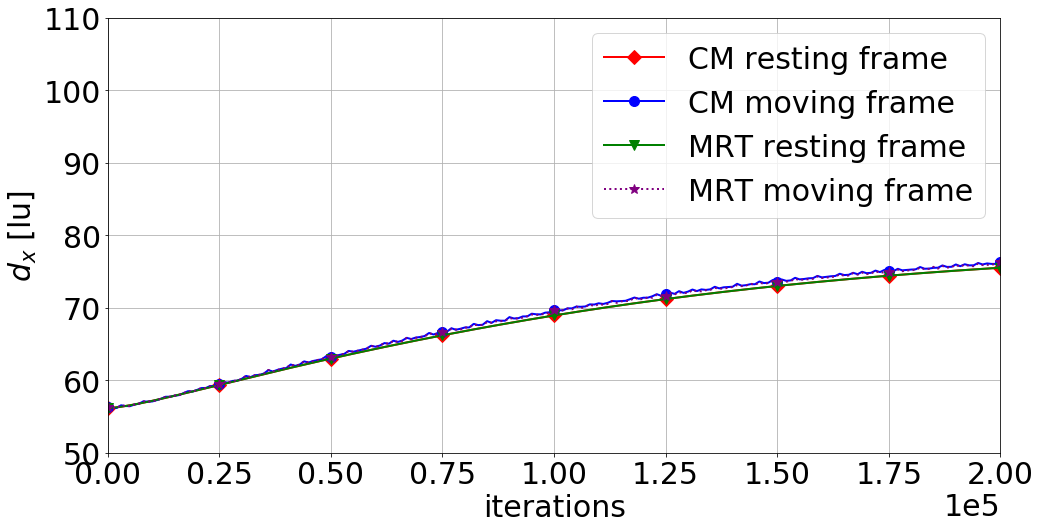

In [14]:
# make plot all in one
# def make_plot(x1, y1, x2, y2, fig_name, y_label, label1, label2):
plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(16, 8))
# The basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step

x = n*1E3

def smooth(x, y):
    to_skip = 1
    new_x = x[0:len(x):to_skip]
    new_y = y[0:len(x):to_skip]

#         xnew = np.linspace(0, max(x), num=len(x), endpoint=False)
    f = interp1d(x, y)
    f2 = interp1d(x, y, kind='cubic')
    return new_x, f2(new_x)

#     x1, y1 =  smooth(x1, y1)
#     x1, y1 =  smooth(x1, y1)

plt.plot(x, diam_x_cm_resting, color="red", marker="D", markevery=25,  markersize=10, linestyle="-", linewidth=2, label='CM resting frame')
plt.plot(x, diam_x_cm_moving, color="blue", marker="o", markevery=25,  markersize=10, linestyle="-", linewidth=2, label='CM moving frame')

plt.plot(x, diam_x_mrt_resting, color="green", marker="v", markevery=25,  markersize=10, linestyle="-", linewidth=2, label="MRT resting frame")
plt.plot(x, diam_x_mrt_moving, color="purple", marker="*", markevery=25,  markersize=10, linestyle=":", linewidth=2, label="MRT moving frame")


axes = plt.gca()
axes.set_xlim([0, 2*1E5])
axes.set_ylim([50, 110])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
#     plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.xlabel(r'iterations')
plt.ylabel(r'$d_x$ [lu]')
plt.grid(True)
plt.legend()

fig = plt.gcf()  # get current figure
fig.savefig(f'bubble_diam_rho{rho_ratio}_v{v}_U{U}_CM_and_MRT.png', )
plt.show()
plt.close(fig)    # close the figure



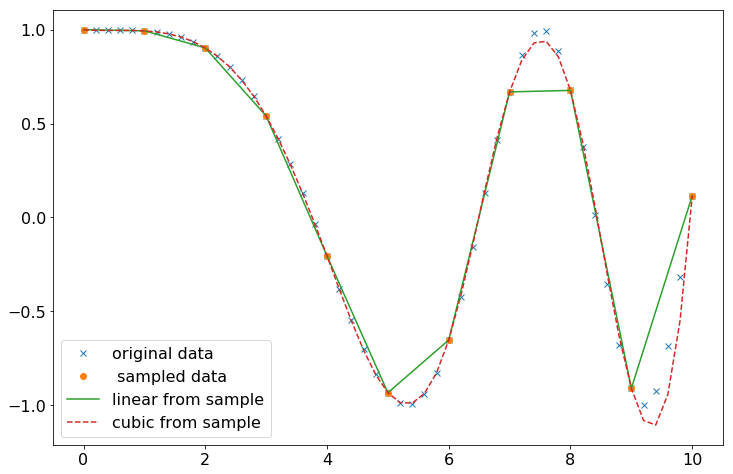

7.2727272727272725


In [47]:

from scipy.interpolate import interp1d
x = np.linspace(0, 10, num=11, endpoint=True)
fun = lambda x: np.cos(-x**2/9.0)
y = fun(x)

f = interp1d(x, y)
f2 = interp1d(x, y, kind='cubic')
xnew = np.linspace(0, 10, num=51, endpoint=True)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 16})
plt.plot(xnew, fun(xnew), 'x')
plt.plot(x, fun(x), 'o', xnew, f(xnew), '-', xnew, f2(xnew), '--')
plt.legend(['original data',' sampled data', 'linear from sample', 'cubic from sample'], loc='best')
plt.show()


def count(x,y, threshold=0.0):
    scale_factor = max(x)/len(x)
    counter = 1
    
    for y_ in y:
        if y_ > threshold:
            counter += 1
                
    ans = counter*scale_factor
    return ans


print(count(x,y))



